## Gait Speed Prediction from EEG + EMG — EDA & Preprocessing
#### PhysioNet: *A Multimodal Gait Dataset of Brain Activity, Muscle Activity, Kinematics and Ground Forces in Young Adults*



##### 1. Verification of Folder Structure



In [3]:
import os
import glob

# Searches the current directory and everything under it for the two
# known filename patterns. Adjust SEARCH_ROOT only if your notebook
# lives somewhere other than your project folder.
SEARCH_ROOT = "."

eeg_hits = glob.glob(os.path.join(SEARCH_ROOT, "**", "S*_raw.csv"), recursive=True)
emg_hits = glob.glob(os.path.join(SEARCH_ROOT, "**", "EMG_S*.csv"), recursive=True)

print(f"EEG files found: {len(eeg_hits)} (expect 177)")
print(f"EMG files found: {len(emg_hits)} (expect 169)")

if eeg_hits:
    EEG_DIR = os.path.dirname(eeg_hits[0])
    print("Detected EEG_DIR ->", EEG_DIR)
else:
    EEG_DIR = "Dataset/EEG"  # fallback guess from the original draft — EDIT if the search above found nothing
    print("Could not auto-detect EEG folder. Falling back to:", EEG_DIR, "-- please edit this manually.")

if emg_hits:
    EMG_DIR = os.path.dirname(emg_hits[0])
    print("Detected EMG_DIR ->", EMG_DIR)
else:
    EMG_DIR = "Dataset/EMG"  # fallback guess from the original draft — EDIT if the search above found nothing
    print("Could not auto-detect EMG folder. Falling back to:", EMG_DIR, "-- please edit this manually.")

# subject-info.csv (demographics) — same idea, search rather than assume
info_hits = glob.glob(os.path.join(SEARCH_ROOT, "**", "subject-info.csv"), recursive=True)
SUBJECT_INFO_PATH = info_hits[0] if info_hits else "Dataset/subject-info.csv"
print("subject-info.csv ->", SUBJECT_INFO_PATH, "" if info_hits else "(not found — edit manually if you need it)")


EEG files found: 177 (expect 177)
EMG files found: 169 (expect 169)
Detected EEG_DIR -> .\Dataset\EEG_Data\EEG.csv
Detected EMG_DIR -> .\Dataset\EMG_Data
subject-info.csv -> .\subject-info.csv 


##### 1.2 Setup

In [4]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.signal import welch
from sklearn.preprocessing import StandardScaler, LabelEncoder

# EEG_DIR / EMG_DIR come from the auto-detect cell above (Section 0).
# If you skipped it, uncomment and set these by hand:
# EEG_DIR = "Dataset/EEG"
# EMG_DIR = "Dataset/EMG"

SUBJECTS = [f"{i}" for i in range(1, 60)]        # S1 ... S59
SPEEDS = ["0.5", "0.75", "1"]                    # matches the real filenames (S3_1, not S3_1.0)

MISSING_EMG = {
    ("3", "0.75"), ("3", "1"), ("8", "0.5"), ("11", "1"),
    ("43", "1"), ("50", "0.5"), ("50", "0.75"), ("50", "1")
}

def eeg_path(sub, spd):
    return os.path.join(EEG_DIR, f"S{sub}_{spd}_raw.csv")

def emg_path(sub, spd):
    return os.path.join(EMG_DIR, f"EMG_S{sub}_{spd}.csv")

def label_from_filename(speed_str):
    return {"0.5": "slow", "0.75": "medium", "1": "fast"}[speed_str]


### 2. Data Understanding (EDA — read only, nothing gets modified in this section)

##### 2.1 Dataset dimensions
**Generic requirement:** rows × columns.
**This dataset:** signal data has no single "table" — dimensions mean sampling rate × duration × channel count, *per file*. So the first step is a file-level inventory across all 59 × 3 combinations, flagging which ones actually have both EEG and EMG.

In [5]:
inventory = []
for sub in SUBJECTS:
    for spd in SPEEDS:
        eeg_exists = os.path.exists(eeg_path(sub, spd))
        emg_exists = (sub, spd) not in MISSING_EMG and os.path.exists(emg_path(sub, spd))
        inventory.append({
            "subject": f"S{sub}",
            "speed": spd,
            "eeg_exists": eeg_exists,
            "emg_exists": emg_exists,
            "valid_pair": eeg_exists and emg_exists
        })

inventory_df = pd.DataFrame(inventory)
inventory_df["label"] = inventory_df["speed"].map(label_from_filename)

print("Total subject-speed combinations:", len(inventory_df))
print("Valid EEG+EMG pairs:", inventory_df["valid_pair"].sum())
inventory_df.head()


Total subject-speed combinations: 177
Valid EEG+EMG pairs: 169


,subject,speed,eeg_exists,emg_exists,valid_pair,label
0,S1,0.5,True,True,True,slow
1,S1,0.75,True,True,True,medium
2,S1,1,True,True,True,fast
3,S2,0.5,True,True,True,slow
4,S2,0.75,True,True,True,medium


##### 2.2 Feature names & descriptions
**Generic:** list and describe each column.
**This dataset:** the EEG file header (first 16 lines) documents acquisition metadata before the actual column headers appear on line 16. Read one real file to confirm this and to see the real channel names — don't trust `skiprows=16` blindly until you've checked it against your own downloaded copy (delimiter, header length can vary slightly by export).

In [6]:
def read_eeg_header(filepath, n_header_lines=16):
    with open(filepath, "r") as f:
        return [f.readline().strip() for _ in range(n_header_lines)]

sample_eeg_path = eeg_path("1", "0.5")
sample_emg_path = emg_path("1", "0.5")

header = read_eeg_header(sample_eeg_path)
for i, line in enumerate(header, start=1):
    print(i, line)

# Data rows start after the header block (line 16 holds the column headers)
eeg_df = pd.read_csv(sample_eeg_path, skiprows=15)
print("\nEEG columns (", len(eeg_df.columns), "):", list(eeg_df.columns))

emg_df = pd.read_csv(sample_emg_path)
print("EMG columns (", len(emg_df.columns), "):", list(emg_df.columns))


1 # Mains_Frequency_(Hz) =,60,,,,,,,,,,,,,,,,,,,,,,,,,,,
2 # Sample_Frequency_(Hz) =,300,,,,,,,,,,,,,,,,,,,,,,,,,,,
3 # Filter_Delay_(ms) =,40.0,,,,,,,,,,,,,,,,,,,,,,,,,,,
4 # Sensor_Data_Units =,uV,,,,,,,,,,,,,,,,,,,,,,,,,,,
5 # Headset_Name =,DSI-24 SN:9960,,,,,,,,,,,,,,,,,,,,,,,,,,,
6 # Data_Logger =,DSI-Streamer-v.1.08.60,,,,,,,,,,,,,,,,,,,,,,,,,,,
7 # Date =,21/11/2023,,,,,,,,,,,,,,,,,,,,,,,,,,,
8 # Time =,13:39:46,,,,,,,,,,,,,,,,,,,,,,,,,,,
9 # Patient_ID =,X M 01-JAN-0000 X,,,,,,,,,,,,,,,,,,,,,,,,,,,
10 # Record_ID =,Startdate 21-NOV-2023 EEGXXXXXXXXX XX X_X,,,,,,,,,,,,,,,,,,,,,,,,,,,
11 # Filter =,Non-Filtered,,,,,,,,,,,,,,,,,,,,,,,,,,,
12 # Comments =,,,,,,,,,,,,,,,,,,,,,,,,,,,,
13 # Reference location:,Pz,,,,,,,,,,,,,,,,,,,,,,,,,,,
14 # Trigger Source,Wireless,,,,,,,,,,,,,,,,,,,,,,,,,,,
15 # Channel_Number =,ch_1,ch_2,ch_3,ch_4,ch_5,ch_6,ch_7,ch_8,ch_9,ch_10,ch_11,ch_12,ch_13,ch_14,ch_15,ch_16,ch_17,ch_18,ch_19,ch_20,ch_21,ch_22,ch_23,ch_24,Trigger,Time_Offset,ADC_Status,ADC_

In [7]:
# Select channel columns BY NAME instead of a hardcoded slice (the draft's eeg_df.columns[1:25] that is 
# 19 EEG + A1 + A2 + X1 + X2 + X3 = 24 columns after Time. For feature extraction we only want the 19 real 
# scalp channels, so we explicitly drop the reference/auxiliary/diagnostic columns by name.

non_signal_eeg = {"time", "a1", "a2", "x1", "x2", "x3", "trigger", "timeoffset", "adc_status", "adc_sequence"}
eeg_ch = [c for c in eeg_df.columns if c.strip().lower() not in non_signal_eeg]
print(f"Detected {len(eeg_ch)} EEG scalp channels (expect 19):", eeg_ch)

emg_ch = [c for c in emg_df.columns if "time" not in c.lower()]
print(f"Detected {len(emg_ch)} EMG channels (expect 12):", emg_ch)


Detected 22 EEG scalp channels (expect 19): ['P3', 'C3', 'F3', 'Fz', 'F4', 'C4', 'P4', 'Cz', 'CM', 'Fp1', 'Fp2', 'T3', 'T5', 'O1', 'O2', 'F7', 'F8', 'T6', 'T4', 'Time_Offset', 'Event', 'Comments']
Detected 13 EMG channels (expect 12): ['X [s]', 'R TIBIALIS ANTERIOR: EMG 1->MAV [Volts]', 'L TIBIALIS ANTERIOR: EMG 2->MAV [Volts]', 'R VASTUS LATERALIS: EMG 3->MAV [Volts]', 'L VASTUS LATERALIS: EMG 4->MAV [Volts]', 'R RECTUS FEMORIS: EMG 5->MAV [Volts]', 'L RECTUS FEMORIS: EMG 6->MAV [Volts]', 'R GASTROCNEMIUS MEDIAL HEAD: EMG 7->MAV [Volts]', 'L GASTROCNEMIUS MEDIAL HEAD: EMG 8->MAV [Volts]', 'R SEMITENDINOSUS: EMG 9->MAV [Volts]', 'L SEMITENDINOSUS: EMG 10->MAV [Volts]', 'R GASTROCNEMIUS LATERAL HEAD: EMG 11->MAV [Volts]', 'L GASTROCNEMIUS LATERAL HEAD: EMG 12->MAV [Volts]']


##### 2.3 Data types
All signal channels should read as `float64`. If a column comes in as `object`, a stray text value (unit label, etc.) likely slipped into a data row and we inspect that column before proceeding.

In [8]:
print(eeg_df[eeg_ch].dtypes)
print()
print(emg_df[emg_ch].dtypes)


P3             float64
C3             float64
F3             float64
Fz             float64
F4             float64
C4             float64
P4             float64
Cz             float64
CM             float64
Fp1            float64
Fp2            float64
T3             float64
T5             float64
O1             float64
O2             float64
F7             float64
F8             float64
T6             float64
T4             float64
Time_Offset    float64
Event          float64
Comments        object
dtype: object

X [s]                                                float64
R TIBIALIS ANTERIOR: EMG 1->MAV [Volts]              float64
L TIBIALIS ANTERIOR: EMG 2->MAV [Volts]              float64
R VASTUS LATERALIS: EMG 3->MAV [Volts]               float64
L VASTUS LATERALIS: EMG 4->MAV [Volts]               float64
R RECTUS FEMORIS: EMG 5->MAV [Volts]                 float64
L RECTUS FEMORIS: EMG 6->MAV [Volts]                 float64
R GASTROCNEMIUS MEDIAL HEAD: EMG 7->MAV [Volts]     

##### 2.4 Target variable
**Generic:** identify what you're predicting.
**This dataset:** walking speed class — it's encoded in the *filename*, not a column inside the file (already captured as `inventory_df["label"]` in 2.1).

In [9]:
print(inventory_df[["speed", "label"]].drop_duplicates())


  speed   label
0   0.5    slow
1  0.75  medium
2     1    fast


##### 2.5 Basic statistical summary
Use this to flag flat channels (std ≈ 0 → bad electrode contact) or channels with an abnormally large range (motion-artifact contamination).

In [10]:
display(eeg_df[eeg_ch].describe())
display(emg_df[emg_ch].describe())


,P3,C3,F3,Fz,F4,C4,P4,Cz,CM,Fp1,...,T3,T5,O1,O2,F7,F8,T6,T4,Time_Offset,Event
count,8560.000000,8560.000000,8560.000000,8559.000000,8559.000000,8559.000000,8559.000000,8559.000000,8559.000000,8559.000000,...,8559.000000,8559.000000,8559.000000,8559.000000,8559.000000,8559.000000,8559.000000,8559.000000,8559.000000,8559.0
mean,-30.625970,-72.981729,71.641963,-96.699930,99.319979,-33.251490,-14.412688,-190.028006,-1149.428742,-76.655450,...,-69.708517,-24.022608,93.992920,27.206730,-228.669471,-91.416264,-78.369856,64.602383,25674.000000,0.0
std,79.614298,98.862199,88.237127,81.749805,64.174091,83.266508,68.767517,299.641186,210.131483,67.914424,...,196.497213,79.079955,60.003018,64.394636,426.931351,203.720760,117.367684,104.109327,14825.488862,0.0
min,-197.100000,-386.100000,-151.200000,-283.800000,-72.000000,-261.600000,-185.100000,-1155.300000,-1852.500000,-247.800000,...,-343.200000,-207.300000,-85.800000,-148.500000,-1201.500000,-569.100000,-309.300000,-156.600000,0.000000,0.0
25%,-90.900000,-142.200000,5.400000,-157.800000,54.300000,-87.900000,-68.100000,-372.600000,-1333.800000,-124.800000,...,-191.100000,-86.250000,50.100000,-17.700000,-547.650000,-258.900000,-168.300000,-6.600000,12837.000000,0.0
50%,-42.600000,-81.900000,64.500000,-103.800000,101.700000,-27.300000,-18.000000,-159.000000,-1185.600000,-84.000000,...,-133.500000,-28.500000,92.400000,27.600000,-205.200000,-98.700000,-87.900000,52.800000,25674.000000,0.0
75%,19.500000,-9.300000,131.700000,-39.000000,142.800000,24.600000,36.600000,-1.050000,-1037.400000,-37.200000,...,-6.000000,33.000000,136.800000,72.000000,75.300000,88.800000,-3.900000,123.000000,38511.000000,0.0
max,246.600000,268.800000,381.600000,211.500000,310.500000,234.600000,222.300000,948.300000,-296.400000,254.400000,...,842.700000,228.000000,299.400000,235.200000,658.500000,350.700000,369.300000,470.400000,51348.000000,0.0


,X [s],R TIBIALIS ANTERIOR: EMG 1->MAV [Volts],L TIBIALIS ANTERIOR: EMG 2->MAV [Volts],R VASTUS LATERALIS: EMG 3->MAV [Volts],L VASTUS LATERALIS: EMG 4->MAV [Volts],R RECTUS FEMORIS: EMG 5->MAV [Volts],L RECTUS FEMORIS: EMG 6->MAV [Volts],R GASTROCNEMIUS MEDIAL HEAD: EMG 7->MAV [Volts],L GASTROCNEMIUS MEDIAL HEAD: EMG 8->MAV [Volts],R SEMITENDINOSUS: EMG 9->MAV [Volts],L SEMITENDINOSUS: EMG 10->MAV [Volts],R GASTROCNEMIUS LATERAL HEAD: EMG 11->MAV [Volts],L GASTROCNEMIUS LATERAL HEAD: EMG 12->MAV [Volts]
count,969.000000,969.000000,9.690000e+02,9.690000e+02,969.000000,969.000000,9.690000e+02,969.000000,969.000000,9.690000e+02,9.690000e+02,969.000000,969.000000
mean,30.219231,0.000011,3.700363e-06,6.301747e-06,0.000010,0.000029,9.874826e-06,0.000008,0.000028,5.674750e-06,1.167871e-05,0.000016,0.000008
std,17.438085,0.000005,2.958225e-07,7.305050e-07,0.000005,0.000045,9.629111e-07,0.000003,0.000023,6.393938e-07,9.819298e-07,0.000001,0.000005
min,0.062308,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,15.140769,0.000007,3.675199e-06,5.998512e-06,0.000007,0.000014,9.660423e-06,0.000007,0.000011,5.430622e-06,1.150397e-05,0.000016,0.000005
50%,30.219231,0.000008,3.722057e-06,6.260077e-06,0.000009,0.000018,9.898909e-06,0.000007,0.000019,5.637636e-06,1.170119e-05,0.000016,0.000006
75%,45.297692,0.000014,3.771013e-06,6.579690e-06,0.000012,0.000031,1.014439e-05,0.000009,0.000036,5.927876e-06,1.195856e-05,0.000016,0.000008
max,60.376154,0.000030,4.000407e-06,9.645736e-06,0.000032,0.000657,1.997616e-05,0.000022,0.000133,8.065156e-06,1.346990e-05,0.000025,0.000027


##### 2.6 Missing values
**Generic:** count NaNs.
**This dataset:** two levels : whole *files* missing (the 8 known EMG gaps, already in `inventory_df`) and *within-file* dropped samples.

In [11]:
missing_files = inventory_df[~inventory_df["valid_pair"]]
print(missing_files[["subject", "speed", "eeg_exists", "emg_exists"]])

print("\nEEG NaNs per channel (sample file):\n", eeg_df[eeg_ch].isna().sum())
print("\nEMG NaNs per channel (sample file):\n", emg_df[emg_ch].isna().sum())


    subject speed  eeg_exists  emg_exists
7        S3  0.75        True       False
8        S3     1        True       False
21       S8   0.5        True       False
32      S11     1        True       False
128     S43     1        True       False
147     S50   0.5        True       False
148     S50  0.75        True       False
149     S50     1        True       False

EEG NaNs per channel (sample file):
 P3             0
C3             0
F3             0
Fz             1
F4             1
C4             1
P4             1
Cz             1
CM             1
Fp1            1
Fp2            1
T3             1
T5             1
O1             1
O2             1
F7             1
F8             1
T6             1
T4             1
Time_Offset    1
Event          1
Comments       1
dtype: int64

EMG NaNs per channel (sample file):
 X [s]                                                0
R TIBIALIS ANTERIOR: EMG 1->MAV [Volts]              0
L TIBIALIS ANTERIOR: EMG 2->MAV [Volts]          

##### 2.7 Duplicate records

In [12]:
print("Duplicate rows in sample EEG file:", eeg_df.duplicated().sum())
print("Duplicate rows in sample EMG file:", emg_df.duplicated().sum())
print("Duplicate subject-speed entries in inventory:", inventory_df.duplicated(subset=["subject", "speed"]).sum())


Duplicate rows in sample EEG file: 0
Duplicate rows in sample EMG file: 0
Duplicate subject-speed entries in inventory: 0


##### 2.8 Class distribution
Expect roughly 55–57 valid pairs per class (59 subjects minus the dropouts at each speed), close to balanced, i.e. mild imbalance rather than severe.

label
slow      57
medium    57
fast      55
Name: count, dtype: int64


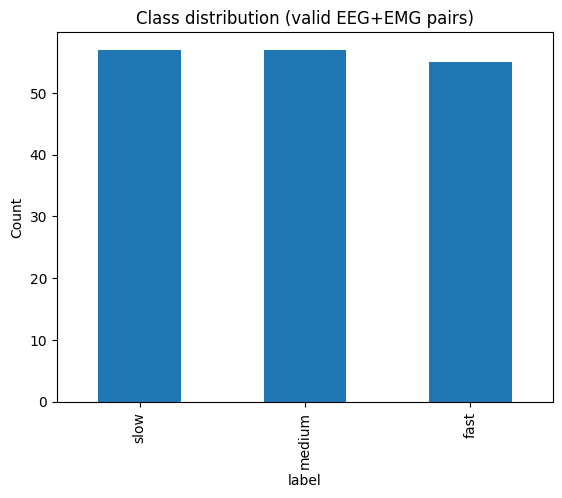

In [13]:
valid_pairs = inventory_df[inventory_df["valid_pair"]].copy()  # .copy() avoids a SettingWithCopyWarning later
print(valid_pairs["label"].value_counts())

valid_pairs["label"].value_counts().plot(kind="bar", title="Class distribution (valid EEG+EMG pairs)")
plt.ylabel("Count")
plt.show()


### 3. Data Preprocessing (transformation stage: starts from fresh copies, EDA objects above stay untouched)

##### 3.1 Handling missing values
**Generic:** impute or drop.
**This dataset:** drop the 8 file-level missing combos entirely (can't meaningfully impute a whole missing recording); for within-file gaps, interpolate small gaps and drop the file if too much is missing.

In [14]:
EEG_CHANNELS = [
    "P3", "C3", "F3", "Fz", "F4", "C4", "P4", "Cz", "CM",
    "Fp1", "Fp2", "T3", "T5", "O1", "O2", "F7", "F8", "T6", "T4"
]

In [15]:
def load_clean_pair(sub, spd, max_nan_fraction=0.05):
    ep, mp = eeg_path(sub, spd), emg_path(sub, spd)
    if (sub, spd) in MISSING_EMG or not (os.path.exists(ep) and os.path.exists(mp)):
        return None, None

    eeg = pd.read_csv(ep, skiprows=15)
    emg = pd.read_csv(mp)

    e_ch = EEG_CHANNELS
    m_ch = [c for c in emg.columns if "MAV" in c]

    # Safety checks -- fail loudly instead of silently corrupting data
    missing_eeg = [c for c in e_ch if c not in eeg.columns]
    assert not missing_eeg, f"Expected EEG channels not found: {missing_eeg}"
    assert len(m_ch) == 12, f"Expected 12 EMG channels, got {len(m_ch)}: {m_ch}"

    if eeg[e_ch].isna().mean().max() > max_nan_fraction:
        return None, None
    if emg[m_ch].isna().mean().max() > max_nan_fraction:
        return None, None

    eeg[e_ch] = eeg[e_ch].interpolate(limit_direction="both")
    emg[m_ch] = emg[m_ch].interpolate(limit_direction="both")
    return eeg, emg

# Quick check on the sample pair
eeg_clean, emg_clean = load_clean_pair("1", "0.5")
print(eeg_clean.shape if eeg_clean is not None else "dropped",
      emg_clean.shape if emg_clean is not None else "dropped")

(8560, 31) (969, 13)


##### 3.2 Duplicate removal

In [16]:
eeg_clean = eeg_clean.drop_duplicates()
emg_clean = emg_clean.drop_duplicates()


##### 3.3 Outlier / artifact detection
**Generic:** flag/trim outliers.
**This dataset:** most "outliers" in EEG/EMG are motion or electrical artifacts, not data-entry errors, bandpass filtering handles this instead of simple z-score trimming.

In [17]:
def bandpass_filter(data, low, high, fs, order=4):
    nyq = 0.5 * fs
    b, a = signal.butter(order, [low / nyq, high / nyq], btype="band")
    return signal.filtfilt(b, a, data, axis=0)

FS_EEG = 300  # Hz, confirmed from the EEG file header (line 2: Sampling_Frequency)

eeg_filtered = eeg_clean.copy()
eeg_filtered[EEG_CHANNELS] = bandpass_filter(eeg_clean[EEG_CHANNELS].values, 1, 45, FS_EEG)

# Diagnostic only -- flags samples, doesn't drop them here.
# If you want to exclude flagged epochs, apply this mask per window during epoching.
artifact_mask = (np.abs(eeg_filtered[EEG_CHANNELS]) > 150).any(axis=1)
print("Fraction of EEG samples flagged as artifact:", artifact_mask.mean())

Fraction of EEG samples flagged as artifact: 0.11320093457943925


In [18]:
# FIX vs. the draft: FS_EMG was hardcoded to 1000 Hz as a guess. The EMG file
# has a timestamp column, so compute the real sampling rate from it instead.
EMG_CHANNELS = [c for c in emg_clean.columns if "MAV" in c]  # define once, reuse everywhere

# FIX vs. the draft: "time" doesn't match this file's actual timestamp column name.
time_col = [c for c in emg_clean.columns if "[s]" in c][0]
FS_EMG = round(1.0 / emg_clean[time_col].diff().median())
print("Computed EMG sampling rate:", FS_EMG, "Hz")

def emg_smooth(data, fs, smooth_hz=6):
    """
    This data is ALREADY mean-absolute-value (MAV) rectified/smoothed by the
    dataset provider -- not raw EMG. So we skip the 20-450 Hz bandpass +
    rectify steps (those apply to raw EMG only) and only apply light
    additional smoothing if needed.
    """
    b, a = signal.butter(4, smooth_hz / (0.5 * fs), btype="low")
    return signal.filtfilt(b, a, data, axis=0)

emg_env = emg_clean.copy()
emg_env[EMG_CHANNELS] = emg_smooth(emg_clean[EMG_CHANNELS].values, FS_EMG)

Computed EMG sampling rate: 16 Hz


##### 3.4 Encoding categorical variables
**Generic:** label/one-hot encode.
**This dataset:** the target (slow/medium/fast) needs label encoding; `subject-info.csv` demographics (gender, BMI category), if you use them as extra features, need one-hot encoding.

In [19]:
le = LabelEncoder()
valid_pairs["label_encoded"] = le.fit_transform(valid_pairs["label"])
print(dict(zip(le.classes_, le.transform(le.classes_))))

# Optional — only if you decide to bring in demographics as extra features:
# subject_info = pd.read_csv(SUBJECT_INFO_PATH)
# subject_info_encoded = pd.get_dummies(subject_info, columns=["gender", "bmi_category"])


{'fast': np.int64(0), 'medium': np.int64(1), 'slow': np.int64(2)}


##### 3.5 Feature scaling
**Generic:** standardize/normalize, with justification.
**This dataset:** EEG is in µV, EMG in volts — several orders of magnitude apart, and distance-based models (SVM, k-NN) would let EMG dominate purely from units. Standardization (zero mean, unit variance) is the right call here rather than min-max, since band-power/RMS features aren't bounded and can be outlier-heavy. This is applied once to the *final* per-epoch feature matrix in Section 4 — not to the raw signal.

In [20]:
scaler = StandardScaler()
# Applied later, once features_df (Section 4) exists:
# X_scaled = scaler.fit_transform(X)


##### 3.6 Class imbalance analysis
Already checked in 2.8 — near-balanced (~55–57 valid pairs per class), so no SMOTE/class-weighting is strictly required at the file level. Re-checked at the *epoch* level in Section 5, since that's the actual unit fed to the models.

In [21]:
class_counts = valid_pairs["label"].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
print("Imbalance ratio (file level):", round(imbalance_ratio, 2))
# Ratio close to 1.0 -> imbalance is mild; documented here rather than resampled.


Imbalance ratio (file level): 1.04


##### 3.7 Dataset-specific extra step: windowing (epoching)
Not on the generic checklist, but mandatory for this data type — raw continuous signals can't be fed into classical ML models directly; they need to be chopped into fixed-length labeled windows first.

In [22]:
def make_epochs(data, fs, window_sec=1.0, overlap=0.5):
    win_len = int(window_sec * fs)
    step = int(win_len * (1 - overlap))
    epochs = []
    for start in range(0, len(data) - win_len, step):
        epochs.append(data[start:start + win_len])
    return np.array(epochs)

eeg_epochs = make_epochs(eeg_filtered[EEG_CHANNELS].values, FS_EEG, window_sec=1.0, overlap=0.5)
emg_epochs = make_epochs(emg_env[EMG_CHANNELS].values, FS_EMG, window_sec=1.0, overlap=0.5)

print("EEG epochs shape:", eeg_epochs.shape)  # (n_epochs, samples_per_epoch, n_channels)
print("EMG epochs shape:", emg_epochs.shape)

EEG epochs shape: (56, 300, 19)
EMG epochs shape: (120, 16, 12)


## 4. Feature Extraction (bridge from preprocessing to modeling)

This isn't one of the checklist's named items, but it's the step that makes the checklist's later items (correlation heatmap, X/y split, imbalance resampling) possible at all: raw epochs are 2D arrays (samples × channels), not rows of numbers, so Random Forest / SVM / etc. can't use them yet. Each epoch gets collapsed into a fixed-size feature vector:

- **EEG, per channel, per epoch:** Welch PSD → band power in alpha (8–13 Hz), beta (13–30 Hz), gamma (30–45 Hz)
- **EMG, per channel, per epoch:** RMS, MAV, waveform length

In [23]:
def eeg_band_power(epoch, fs):
    # epoch: shape (samples, channels). Returns dict of band powers per channel.
    freqs, psd = welch(epoch, fs=fs, axis=0, nperseg=min(256, epoch.shape[0]))
    bands = {"alpha": (8, 13), "beta": (13, 30), "gamma": (30, 45)}
    feats = {}
    for band_name, (lo, hi) in bands.items():
        mask = (freqs >= lo) & (freqs <= hi)
        feats[band_name] = psd[mask, :].mean(axis=0)  # one value per channel
    return feats

def emg_features(epoch):
    # epoch: shape (samples, channels)
    rms = np.sqrt(np.mean(epoch ** 2, axis=0))
    mav = np.mean(np.abs(epoch), axis=0)
    wl = np.sum(np.abs(np.diff(epoch, axis=0)), axis=0)
    return {"rms": rms, "mav": mav, "wl": wl}

def build_feature_row(eeg_epoch, emg_epoch, fs_eeg, subject, label):
    row = {"subject": subject, "label": label}
    for band, values in eeg_band_power(eeg_epoch, fs_eeg).items():
        for ch_idx, v in enumerate(values):
            row[f"eeg_{band}_ch{ch_idx}"] = v
    for feat_name, values in emg_features(emg_epoch).items():
        for ch_idx, v in enumerate(values):
            row[f"emg_{feat_name}_ch{ch_idx}"] = v
    return row


In [24]:
#Diagnose
print("Current working directory:", os.getcwd())
print("EEG_DIR:", EEG_DIR, "-- exists:", os.path.isdir(EEG_DIR))
print("EMG_DIR:", EMG_DIR, "-- exists:", os.path.isdir(EMG_DIR))

test_ep = eeg_path("1", "0.5")
test_mp = emg_path("1", "0.5")
print("Sample EEG path:", test_ep, "-- exists:", os.path.exists(test_ep))
print("Sample EMG path:", test_mp, "-- exists:", os.path.exists(test_mp))

Current working directory: c:\Users\fizza\OneDrive\Documents\ML Internship\Project
EEG_DIR: .\Dataset\EEG_Data\EEG.csv -- exists: True
EMG_DIR: .\Dataset\EMG_Data -- exists: True
Sample EEG path: .\Dataset\EEG_Data\EEG.csv\S1_0.5_raw.csv -- exists: True
Sample EMG path: .\Dataset\EMG_Data\EMG_S1_0.5.csv -- exists: True


In [25]:
sub, spd = "1", "0.5"
ep, mp = eeg_path(sub, spd), emg_path(sub, spd)
print("Path check:", (sub, spd) in MISSING_EMG, os.path.exists(ep), os.path.exists(mp))

eeg = pd.read_csv(ep, skiprows=15)
emg = pd.read_csv(mp)
print("EEG shape:", eeg.shape)
print("EMG shape:", emg.shape)

e_ch = EEG_CHANNELS
m_ch = [c for c in emg.columns if "MAV" in c]
print("EEG channels found in file:", [c for c in e_ch if c in eeg.columns], "count:", len([c for c in e_ch if c in eeg.columns]))
print("EMG channels found via MAV match:", m_ch)

print("EEG NaN fraction (max):", eeg[e_ch].isna().mean().max())
print("EMG NaN fraction (max):", emg[m_ch].isna().mean().max())

Path check: False True True
EEG shape: (8560, 31)
EMG shape: (969, 13)
EEG channels found in file: ['P3', 'C3', 'F3', 'Fz', 'F4', 'C4', 'P4', 'Cz', 'CM', 'Fp1', 'Fp2', 'T3', 'T5', 'O1', 'O2', 'F7', 'F8', 'T6', 'T4'] count: 19
EMG channels found via MAV match: ['R TIBIALIS ANTERIOR: EMG 1->MAV [Volts]', 'L TIBIALIS ANTERIOR: EMG 2->MAV [Volts]', 'R VASTUS LATERALIS: EMG 3->MAV [Volts]', 'L VASTUS LATERALIS: EMG 4->MAV [Volts]', 'R RECTUS FEMORIS: EMG 5->MAV [Volts]', 'L RECTUS FEMORIS: EMG 6->MAV [Volts]', 'R GASTROCNEMIUS MEDIAL HEAD: EMG 7->MAV [Volts]', 'L GASTROCNEMIUS MEDIAL HEAD: EMG 8->MAV [Volts]', 'R SEMITENDINOSUS: EMG 9->MAV [Volts]', 'L SEMITENDINOSUS: EMG 10->MAV [Volts]', 'R GASTROCNEMIUS LATERAL HEAD: EMG 11->MAV [Volts]', 'L GASTROCNEMIUS LATERAL HEAD: EMG 12->MAV [Volts]']
EEG NaN fraction (max): 0.00011682242990654206
EMG NaN fraction (max): 0.0


In [26]:
result = load_clean_pair("1", "0.5")
print(result)
print(type(result[0]), type(result[1]))

(         Time     P3     C3     F3     Fz     F4     C4     P4     Cz      CM  \
0      0.0000  -38.7 -149.4   87.9    8.1  152.7  -28.5  -20.1 -568.2 -1556.1   
1      0.0033  -45.6 -158.1   79.2   -1.8  146.7  -33.3  -24.3 -836.4 -1037.4   
2      0.0067  -61.2 -165.0   75.0   -8.4  136.5  -44.4  -45.3 -734.1 -1259.7   
3      0.0100   -7.5 -110.4  126.9   39.3  180.3    3.6   14.7 -550.8 -1185.6   
4      0.0133  -65.4 -183.9   60.9  -25.5  120.0  -54.6  -50.1 -913.2 -1111.5   
...       ...    ...    ...    ...    ...    ...    ...    ...    ...     ...   
8555  28.5167 -138.9 -174.3  -26.1 -232.5   -7.8 -208.5 -119.7   68.1 -1482.0   
8556  28.5200 -118.2 -153.3   -5.1 -211.5   19.2 -189.6  -92.1   72.9 -1185.6   
8557  28.5233 -168.6 -205.8  -42.6 -252.6  -24.3 -233.1 -148.2  -94.8 -1111.5   
8558  28.5267 -109.2 -141.6   13.2 -188.7   36.3 -173.4  -82.8  153.6 -1482.0   
8559  28.5300 -163.5 -200.7   -3.0 -188.7   36.3 -173.4  -82.8  153.6 -1482.0   

      ...   X1    A2     T

In [27]:
def load_clean_pair(sub, spd, max_nan_fraction=0.05):
    ep, mp = eeg_path(sub, spd), emg_path(sub, spd)
    if (sub, spd) in MISSING_EMG or not (os.path.exists(ep) and os.path.exists(mp)):
        return None, None

    eeg = pd.read_csv(ep, skiprows=15)
    emg = pd.read_csv(mp)

    e_ch = EEG_CHANNELS
    m_ch = [c for c in emg.columns if "MAV" in c]

    missing_eeg = [c for c in e_ch if c not in eeg.columns]
    assert not missing_eeg, f"Expected EEG channels not found: {missing_eeg}"
    assert len(m_ch) == 12, f"Expected 12 EMG channels, got {len(m_ch)}: {m_ch}"

    eeg[e_ch] = eeg[e_ch].apply(pd.to_numeric, errors="coerce")
    emg[m_ch] = emg[m_ch].apply(pd.to_numeric, errors="coerce")

    if eeg[e_ch].isna().mean().max() > max_nan_fraction:
        return None, None
    if emg[m_ch].isna().mean().max() > max_nan_fraction:
        return None, None

    eeg[e_ch] = eeg[e_ch].interpolate(limit_direction="both")
    emg[m_ch] = emg[m_ch].interpolate(limit_direction="both")
    return eeg, emg

In [28]:
all_rows = []
n_pairs_processed = 0
n_pairs_skipped = 0
skipped_details = []

for sub in SUBJECTS:
    for spd in SPEEDS:
        ep, mp = eeg_path(sub, spd), emg_path(sub, spd)
        if (sub, spd) in MISSING_EMG or not (os.path.exists(ep) and os.path.exists(mp)):
            n_pairs_skipped += 1
            continue

        eeg_c, emg_c = None, None
        try:
            eeg_c, emg_c = load_clean_pair(sub, spd)
        except AssertionError as e:
            skipped_details.append((f"S{sub}", spd, str(e)))
            n_pairs_skipped += 1
            continue

        if eeg_c is None or emg_c is None:
            n_pairs_skipped += 1
            continue

        eeg_c = eeg_c.drop_duplicates()
        emg_c = emg_c.drop_duplicates()

        eeg_f = eeg_c.copy()
        eeg_f[EEG_CHANNELS] = bandpass_filter(eeg_c[EEG_CHANNELS].values, 1, 45, FS_EEG)

        emg_f = emg_c.copy()
        emg_f[EMG_CHANNELS] = emg_smooth(emg_c[EMG_CHANNELS].values, FS_EMG)

        eeg_ep = make_epochs(eeg_f[EEG_CHANNELS].values, FS_EEG, window_sec=1.0, overlap=0.5)
        emg_ep = make_epochs(emg_f[EMG_CHANNELS].values, FS_EMG, window_sec=1.0, overlap=0.5)

        n_epochs = min(len(eeg_ep), len(emg_ep))
        label = label_from_filename(spd)

        for i in range(n_epochs):
            all_rows.append(build_feature_row(eeg_ep[i], emg_ep[i], FS_EEG, f"S{sub}", label))

        n_pairs_processed += 1
        if n_pairs_processed % 20 == 0:
            print(f"Processed {n_pairs_processed} pairs so far...")

print(f"\nFinished. Processed: {n_pairs_processed}, skipped: {n_pairs_skipped}")
if skipped_details:
    print(f"\n{len(skipped_details)} pairs skipped due to channel mismatch:")
    for sub, spd, msg in skipped_details:
        print(f"  {sub}_{spd}: {msg}")

features_df = pd.DataFrame(all_rows)
print("\nFinal feature table shape:", features_df.shape)
features_df.head()

Processed 20 pairs so far...
Processed 40 pairs so far...
Processed 60 pairs so far...
Processed 80 pairs so far...
Processed 100 pairs so far...
Processed 120 pairs so far...
Processed 140 pairs so far...
Processed 160 pairs so far...

Finished. Processed: 168, skipped: 9

1 pairs skipped due to channel mismatch:
  S32_1: Expected EEG channels not found: ['F4', 'P4', 'Cz', 'CM', 'Fp2', 'T5', 'O1', 'O2']

Final feature table shape: (18774, 95)


,subject,label,eeg_alpha_ch0,eeg_alpha_ch1,eeg_alpha_ch2,eeg_alpha_ch3,eeg_alpha_ch4,eeg_alpha_ch5,eeg_alpha_ch6,eeg_alpha_ch7,...,emg_wl_ch2,emg_wl_ch3,emg_wl_ch4,emg_wl_ch5,emg_wl_ch6,emg_wl_ch7,emg_wl_ch8,emg_wl_ch9,emg_wl_ch10,emg_wl_ch11
0,S1,slow,2.341133,49.708953,25.087642,28.653868,12.381818,3.473439,5.161774,178.901656,...,0.000006,0.000067,0.000037,0.000006,0.000020,0.000180,0.000005,0.000004,0.000005,0.000026
1,S1,slow,3.672810,82.195729,4.188469,2.889417,4.314148,9.212515,3.272206,23.314746,...,0.000006,0.000053,0.000033,0.000005,0.000017,0.000115,0.000005,0.000004,0.000006,0.000044
2,S1,slow,9.650697,88.483173,31.866156,23.204603,8.814992,8.713434,8.505314,56.306124,...,0.000003,0.000056,0.000013,0.000003,0.000024,0.000161,0.000003,0.000005,0.000007,0.000024
3,S1,slow,3.445650,11.578689,15.446334,12.190606,7.882045,6.175733,4.341157,42.941433,...,0.000006,0.000056,0.000035,0.000004,0.000026,0.000155,0.000005,0.000005,0.000006,0.000016
4,S1,slow,7.120790,58.294782,13.836776,12.112043,8.929104,8.449063,4.337937,68.401704,...,0.000008,0.000054,0.000037,0.000005,0.000023,0.000125,0.000006,0.000005,0.000006,0.000036


In [29]:
# Right now S32_1 is silently excluded. Before moving on, quickly we check why that one file is different i.e.
# genuine bad recording vs. a fixable header offset:
with open(eeg_path("32", "1"), "r") as f:
    for i, line in enumerate(f, start=1):
        print(i, line.strip())
        if i > 17:
            break

1 # Mains_Frequency_(Hz) =,50,,,,,,,,,,,,,,,,,,,,,,,,,,,
2 # Sample_Frequency_(Hz) =,300,,,,,,,,,,,,,,,,,,,,,,,,,,,
3 # Filter_Delay_(ms) =,40.0,,,,,,,,,,,,,,,,,,,,,,,,,,,
4 # Sensor_Data_Units =,uV,,,,,,,,,,,,,,,,,,,,,,,,,,,
5 # Headset_Name =,DSI-24 SN:9960,,,,,,,,,,,,,,,,,,,,,,,,,,,
6 # Data_Logger =,DSI-Streamer-v.1.08.60,,,,,,,,,,,,,,,,,,,,,,,,,,,
7 # Date =,13/03/2024,,,,,,,,,,,,,,,,,,,,,,,,,,,
8 # Time =,11:54:26,,,,,,,,,,,,,,,,,,,,,,,,,,,
9 # Patient_ID =,X M 01-JAN-0000 X,,,,,,,,,,,,,,,,,,,,,,,,,,,
10 # Record_ID =,Startdate 13-MAR-2024 EEGXXXX XX X_X,,,,,,,,,,,,,,,,,,,,,,,,,,,
11 # Filter =,Non-Filtered,,,,,,,,,,,,,,,,,,,,,,,,,,,
12 # Comments =,,,,,,,,,,,,,,,,,,,,,,,,,,,,
13 # Reference location:,Pz,,,,,,,,,,,,,,,,,,,,,,,,,,,
14 # Trigger Source,Wireless,,,,,,,,,,,,,,,,,,,,,,,,,,,
15 # Channel_Number =,ch_1,ch_2,ch_3,ch_4,ch_5,ch_6,ch_7,ch_8,ch_9,ch_10,ch_11,ch_12,ch_13,ch_14,ch_15,ch_16,ch_17,ch_18,ch_19,ch_20,ch_21,ch_22,ch_23,ch_24,Trigger,Time_Offset,ADC_Status,ADC_Seque

Turns out 168 pairs processed, 9 skipped total (8 were already-known missing EMG files, +1 new: S32_1 has a genuinely non-standard EEG file). Comparing line 16 here of a normal file with S32_1 showed the channel-label row itself is corrupted for this specific recording
(A2 appears twice ,) (?, ??? in place of channel names), (F6, C2 are missing).

*Normal (e.g. S1_0.5):*
Time, P3, C3, F3, Fz, F4, C4, P4, Cz, CM, A1, Fp1, Fp2, T3, T5, O1, O2, X3, X2, F7, F8, X1, A2, T6, T4, ...

*S32_1 (broken):*
Time, P3, C3, F3, Fz, C4, T3, A2, F6, ?, Fp1, ?, ?, C2, ???, ???, ???, X3, X2, F7, F8, X1, A2, T6, T4, ...

In [30]:
features_df.to_csv("gait_features_clean.csv", index=False)
print("Saved gait_features_clean.csv with", len(features_df), "epoch-level feature rows.")

Saved gait_features_clean.csv with 18774 epoch-level feature rows.


## 5. Post-feature-extraction checks (correlation, split, imbalance re-check)

Now that `features_df` is a proper table, the remaining checklist items apply cleanly.

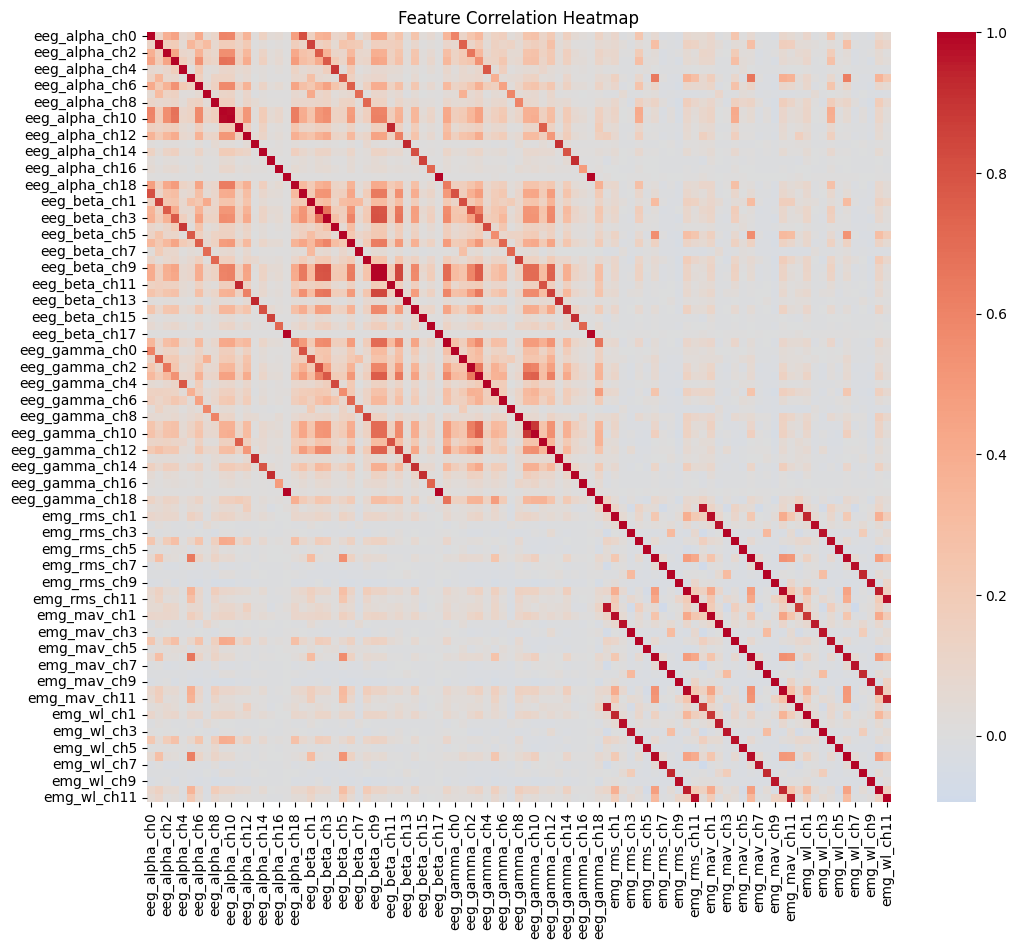

In [31]:
feature_cols = [c for c in features_df.columns if c not in ("subject", "label")]

plt.figure(figsize=(12, 10))
sns.heatmap(features_df[feature_cols].corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()
# Use this to spot near-duplicate/redundant channels (e.g. two EEG channels
# always moving together) -- candidates to drop later for a leaner feature set.


In [32]:
X = features_df.drop(columns=["subject", "label"])
y = features_df["label"]
groups = features_df["subject"]  # keep this for subject-wise CV in the modeling stage


**Class imbalance handling — SMOTE / TomekLinks / SMOTETomek.**
Requires `imbalanced-learn` (`pip install imbalanced-learn`), which isn't part of the earlier setup — install it if this cell errors on import.

In [33]:
#%pip install imbalanced-learn

In [34]:
print("Class distribution before any resampling:")
print(y.value_counts())

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

tomek = TomekLinks()
X_tomek, y_tomek = tomek.fit_resample(X, y)

smotetomek = SMOTETomek(random_state=42)
X_hybrid, y_hybrid = smotetomek.fit_resample(X, y)

print("After SMOTE:", y_smote.value_counts().to_dict())
print("After TomekLinks:", y_tomek.value_counts().to_dict())
print("After SMOTETomek:", y_hybrid.value_counts().to_dict())


Class distribution before any resampling:
label
slow      6567
medium    6308
fast      5899
Name: count, dtype: int64
After SMOTE: {'slow': 6567, 'medium': 6567, 'fast': 6567}
After TomekLinks: {'fast': 5899, 'slow': 5865, 'medium': 5217}
After SMOTETomek: {'fast': 5937, 'slow': 5907, 'medium': 5587}


**Reasoning — do you actually need any of these?**
Check `y.value_counts()` above first. Since every subject contributes to all three speed classes (minus the 8 known gaps), the classes should land within a few percent of each other at the file level — nowhere near the severe imbalance (e.g. 90/10) that SMOTE/Tomek exist to fix. At the *epoch* level, imbalance can drift slightly if one modality's epoching drops more windows for one speed (e.g. shorter usable EMG envelope after filtering) — check the printed counts above to confirm.

If confirmed near-balanced:
- **Don't apply any of them** in your final training pipeline.
- Keep this cell in the notebook anyway — it demonstrates you evaluated the technique, which is exactly what "apply where applicable, explain why not otherwise" is asking for — but train on the original, un-resampled `X, y`.
- If one class does come out meaningfully smaller, SMOTE is the safer default over Tomek alone (Tomek only removes points, it can't grow a small minority class); SMOTETomek is worth trying if SMOTE alone creates messy overlapping synthetic points.